<a href="https://colab.research.google.com/github/sreevathsa888/Oleti_Sree_Vathsa/blob/main/EDA_Course_Project_23BDS0143_Males_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1 - Exploratory Data Analysis Course Project

Name: Oleti Sree Vathsa
Register Number: 23BDS0143

In [8]:

# PHASE 1 - EXPLORATORY DATA ANALYSIS
# Name : Oleti Sree Vathsa
# Reg No : 23BDS0143


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")

In [9]:


url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Males.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print()

df.head()

Dataset Loaded Successfully



,rownames,nr,year,school,exper,union,ethn,maried,health,wage,industry,occupation,residence
0,1,13,1980,14,1,no,other,no,no,1.197540,Business_and_Repair_Service,Service_Workers,north_east
1,2,13,1981,14,2,yes,other,no,no,1.853060,Personal_Service,Service_Workers,north_east
2,3,13,1982,14,3,no,other,no,no,1.344462,Business_and_Repair_Service,Service_Workers,north_east
3,4,13,1983,14,4,no,other,no,no,1.433213,Business_and_Repair_Service,Service_Workers,north_east
4,5,13,1984,14,5,no,other,no,no,1.568125,Personal_Service,"Craftsmen, Foremen_and_kindred",north_east


In [10]:
print("Shape of Dataset :", df.shape)

print("\nColumn Names\n")
print(df.columns)

print("\nDataset Information\n")
df.info()

Shape of Dataset : (4360, 13)

Column Names

Index(['rownames', 'nr', 'year', 'school', 'exper', 'union', 'ethn', 'maried',
       'health', 'wage', 'industry', 'occupation', 'residence'],
      dtype='object')

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4360 entries, 0 to 4359
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rownames    4360 non-null   int64  
 1   nr          4360 non-null   int64  
 2   year        4360 non-null   int64  
 3   school      4360 non-null   int64  
 4   exper       4360 non-null   int64  
 5   union       4360 non-null   object 
 6   ethn        4360 non-null   object 
 7   maried      4360 non-null   object 
 8   health      4360 non-null   object 
 9   wage        4360 non-null   float64
 10  industry    4360 non-null   object 
 11  occupation  4360 non-null   object 
 12  residence   3115 non-null   object 
dtypes: float64(1), int64(5), object(7)
memor

In [11]:
print("Basic Statistical Analysis")

df.describe(include='all')

Basic Statistical Analysis


,rownames,nr,year,school,exper,union,ethn,maried,health,wage,industry,occupation,residence
count,4360.000000,4360.000000,4360.000000,4360.000000,4360.000000,4360,4360,4360,4360,4360.000000,4360,4360,3115
unique,NaN,NaN,NaN,NaN,NaN,2,3,2,2,NaN,12,9,4
top,NaN,NaN,NaN,NaN,NaN,no,other,no,no,NaN,Manufacturing,"Craftsmen, Foremen_and_kindred",south
freq,NaN,NaN,NaN,NaN,NaN,3296,3176,2446,4286,NaN,1231,934,1333
mean,2180.500000,5262.058716,1983.500000,11.766972,6.514679,NaN,NaN,NaN,NaN,1.649147,NaN,NaN,NaN
std,1258.767916,3496.149815,2.291551,1.746181,2.825873,NaN,NaN,NaN,NaN,0.532609,NaN,NaN,NaN
min,1.000000,13.000000,1980.000000,3.000000,0.000000,NaN,NaN,NaN,NaN,-3.579079,NaN,NaN,NaN
25%,1090.750000,2329.000000,1981.750000,11.000000,4.000000,NaN,NaN,NaN,NaN,1.350717,NaN,NaN,NaN
50%,2180.500000,4569.000000,1983.500000,12.000000,6.000000,NaN,NaN,NaN,NaN,1.671143,NaN,NaN,NaN
75%,3270.250000,8406.000000,1985.250000,12.000000,9.000000,NaN,NaN,NaN,NaN,1.991086,NaN,NaN,NaN


In [12]:
print("Missing Values")

df.isnull().sum()

Missing Values


,0
rownames,0
nr,0
year,0
school,0
exper,0
union,0
ethn,0
maried,0
health,0
wage,0


In [13]:
# Fill Numerical Missing Values

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Missing Values

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully.")

df.isnull().sum()

Missing values handled successfully.


,0
rownames,0
nr,0
year,0
school,0
exper,0
union,0
ethn,0
maried,0
health,0
wage,0


In [14]:
# Remove Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates :", df.shape)

Duplicate Records : 0
Dataset Shape After Removing Duplicates : (4360, 13)


In [15]:
# Encoding for Categorical Columns

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Categorical columns transformed successfully.")

df.head()

Categorical columns transformed successfully.


,rownames,nr,year,school,exper,union,ethn,maried,health,wage,industry,occupation,residence
0,1,13,1980,14,1,0,2,0,0,1.197540,1,8,0
1,2,13,1981,14,2,1,2,0,0,1.853060,7,8,0
2,3,13,1982,14,3,0,2,0,0,1.344462,1,8,0
3,4,13,1983,14,4,0,2,0,0,1.433213,1,8,0
4,5,13,1984,14,5,0,2,0,0,1.568125,7,1,0


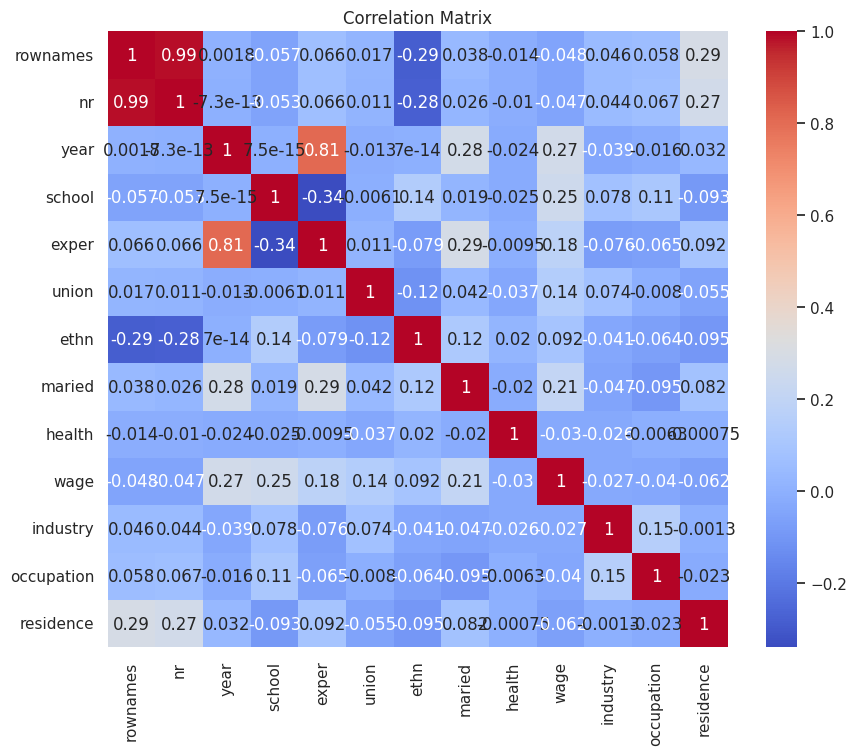

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

UNIVARIATE ANALYSIS

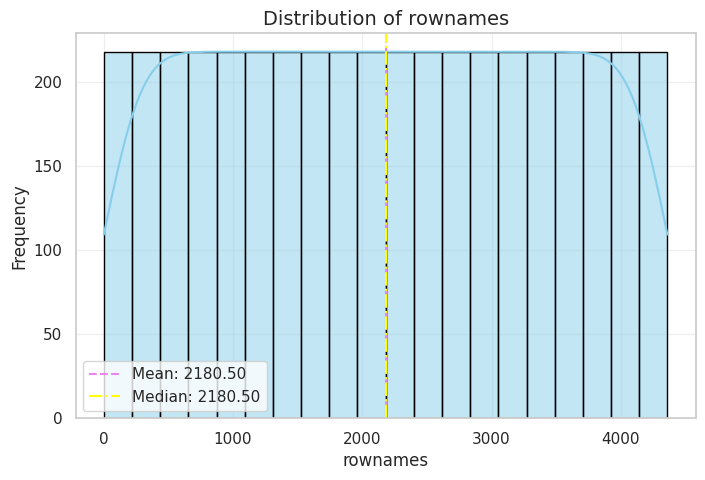

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df[num_cols[0]], bins=20, kde=True, color='skyblue', edgecolor='black')

mean_val = df[num_cols[0]].mean()
median_val = df[num_cols[0]].median()

plt.axvline(mean_val, color='violet', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='yellow', linestyle='-.', linewidth=1.5, label=f'Median: {median_val:.2f}')

plt.title(f'Distribution of {num_cols[0]}', fontsize=14)
plt.xlabel(num_cols[0], fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

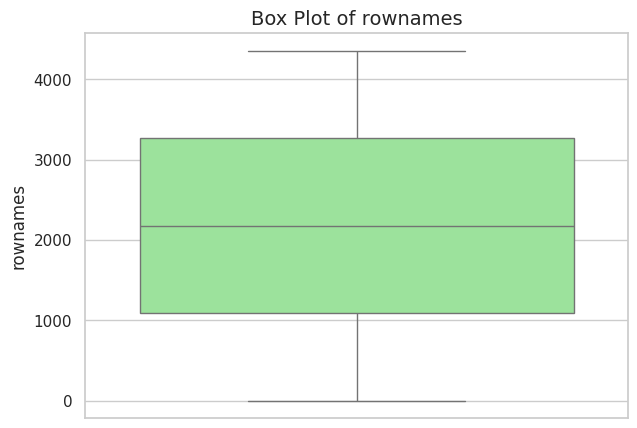

In [18]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df[num_cols[0]], color='lightgreen')

plt.title(f'Box Plot of {num_cols[0]}', fontsize=14)

plt.xlabel('')

plt.ylabel(num_cols[0], fontsize=12)

plt.show()

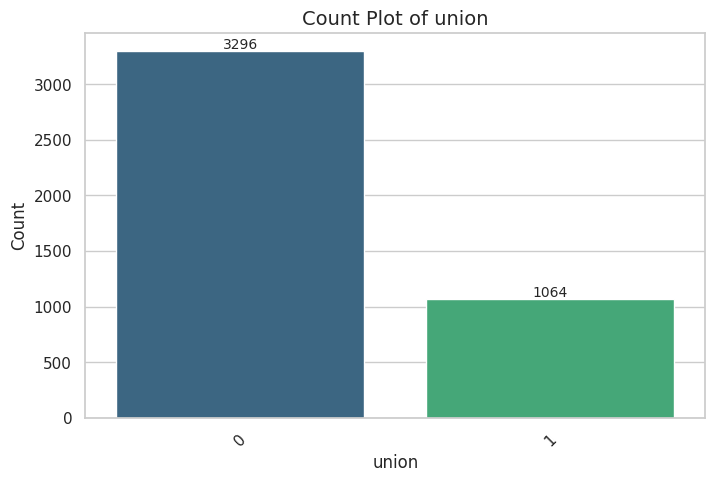

In [19]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x=df[categorical_columns[0]], palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title(f'Count Plot of {categorical_columns[0]}', fontsize=14)
plt.xlabel(categorical_columns[0], fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

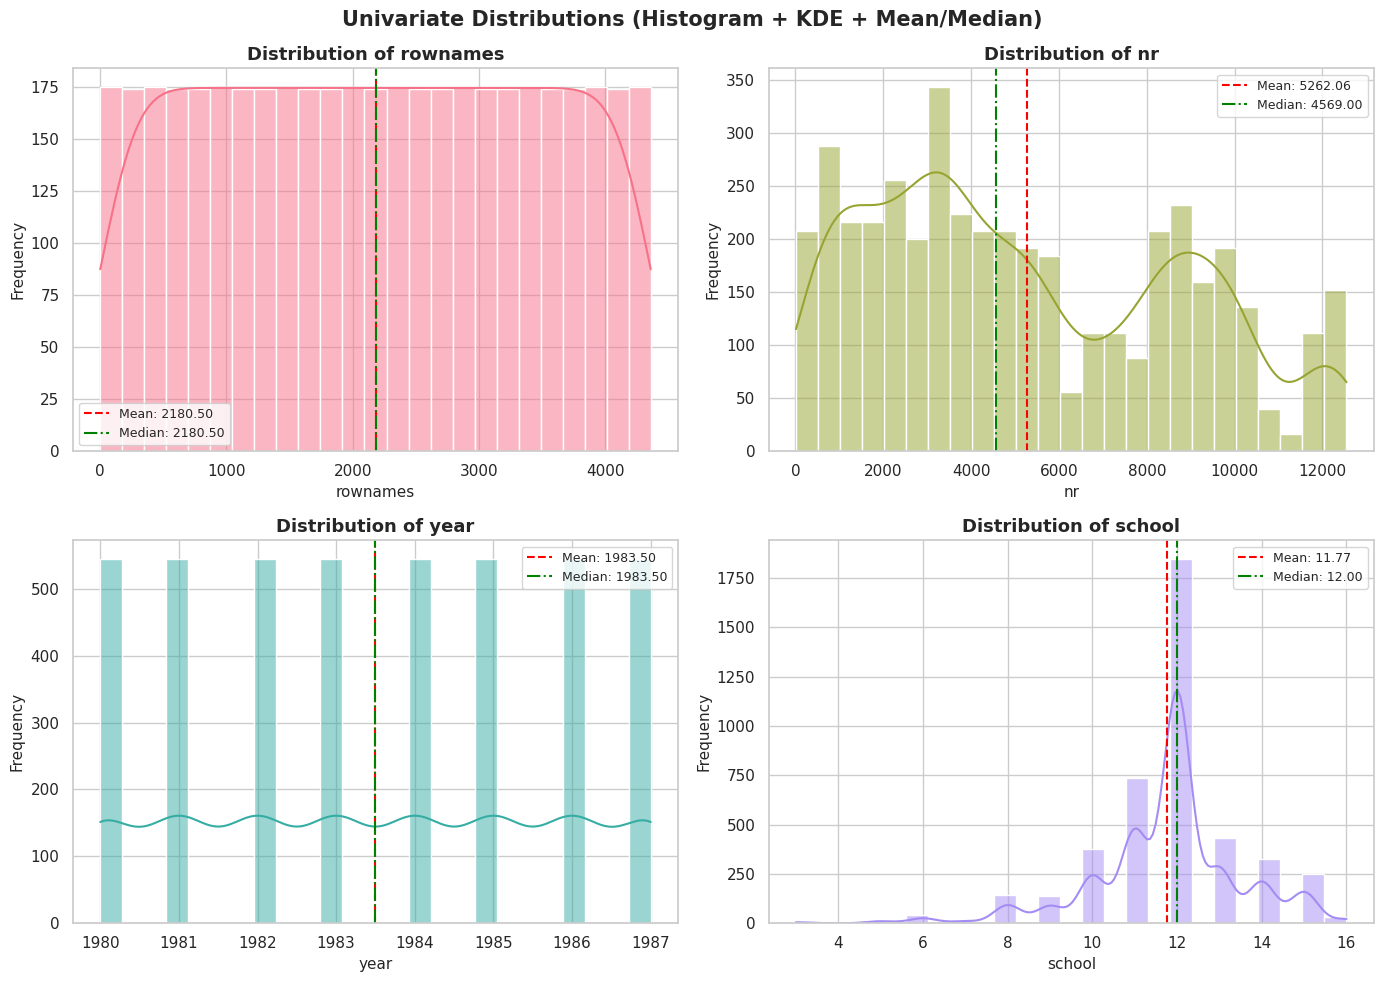

In [20]:
cols_to_plot = num_cols[:4] if len(num_cols) >= 4 else num_cols

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, bins=25, color=sns.color_palette("husl", 4)[i], ax=axes[i])
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-.', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].legend(fontsize=9)

for j in range(len(cols_to_plot), 4):
    fig.delaxes(axes[j])

plt.suptitle("Univariate Distributions (Histogram + KDE + Mean/Median)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Bivariate Analysis

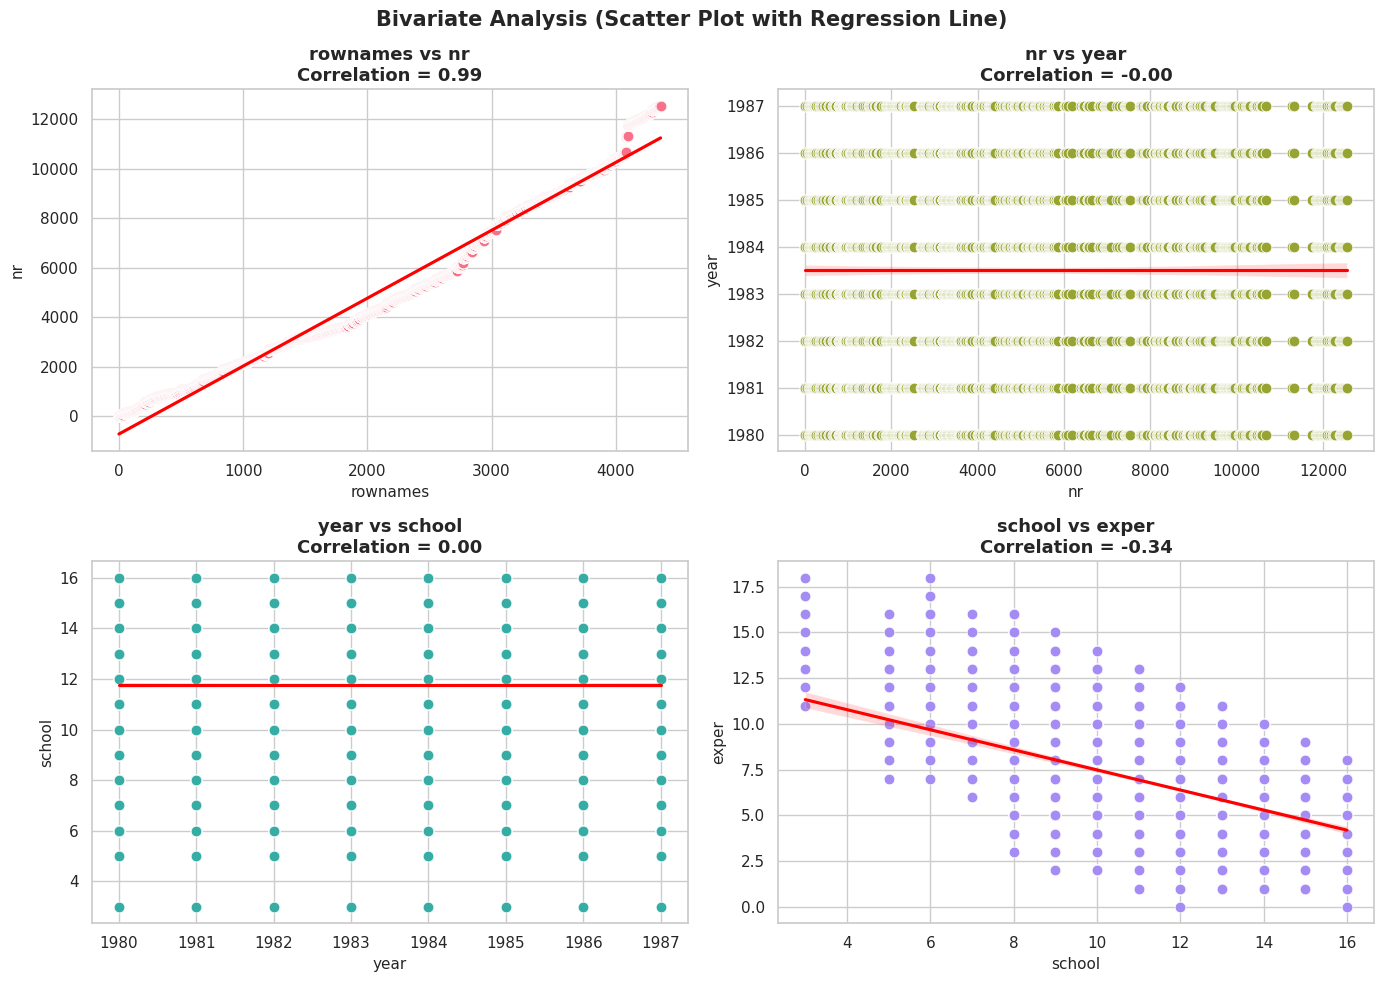

In [21]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

pairs = [(num_cols[i], num_cols[i+1]) for i in range(min(len(num_cols)-1, 4))]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(pairs):

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        color=sns.color_palette("husl",4)[i],
        s=60,
        ax=axes[i]
    )

    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter=False,
        color='red',
        ax=axes[i]
    )

    corr = df[[x_col, y_col]].corr().iloc[0,1]

    axes[i].set_title(
        f'{x_col} vs {y_col}\nCorrelation = {corr:.2f}',
        fontsize=13,
        fontweight='bold'
    )

    axes[i].set_xlabel(x_col, fontsize=11)
    axes[i].set_ylabel(y_col, fontsize=11)

for j in range(len(pairs), 4):
    fig.delaxes(axes[j])

plt.suptitle("Bivariate Analysis (Scatter Plot with Regression Line)", fontsize=15, fontweight='bold')

plt.tight_layout()

plt.show()

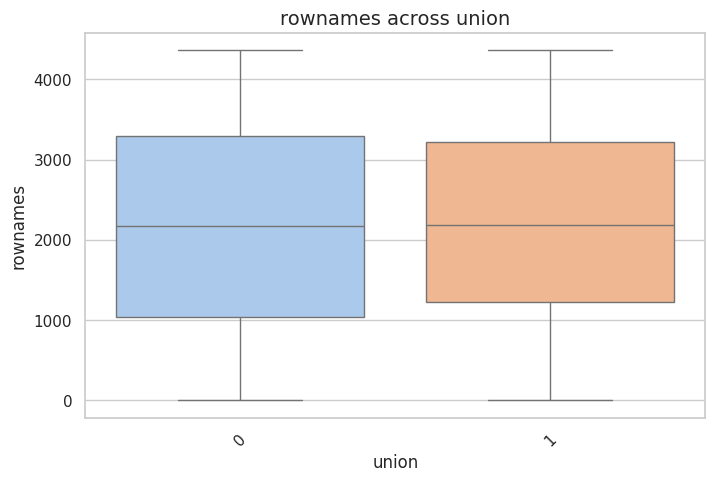

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df[categorical_columns[0]], y=df[num_cols[0]], palette='pastel')

plt.title(f'{num_cols[0]} across {categorical_columns[0]}', fontsize=14)
plt.xlabel(categorical_columns[0], fontsize=12)
plt.ylabel(num_cols[0], fontsize=12)
plt.xticks(rotation=45)
plt.show()

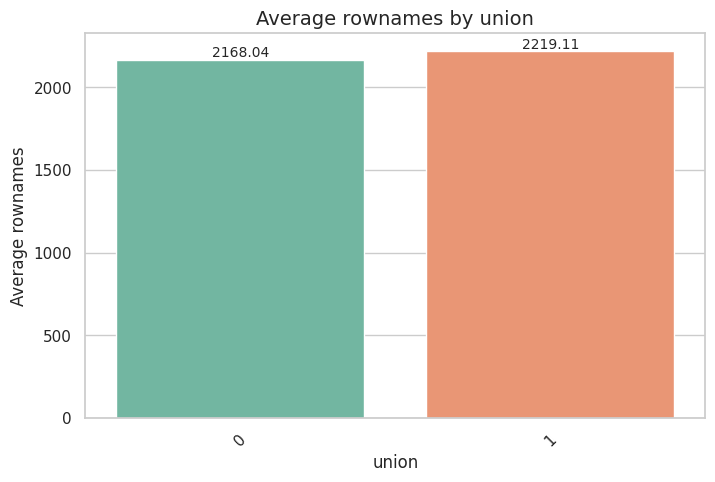

In [23]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=df[categorical_columns[0]], y=df[num_cols[0]],
                  estimator=np.mean, palette='Set2', ci=None)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

plt.title(f'Average {num_cols[0]} by {categorical_columns[0]}', fontsize=14)
plt.xlabel(categorical_columns[0], fontsize=12)
plt.ylabel(f'Average {num_cols[0]}', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Multivariate Analysis

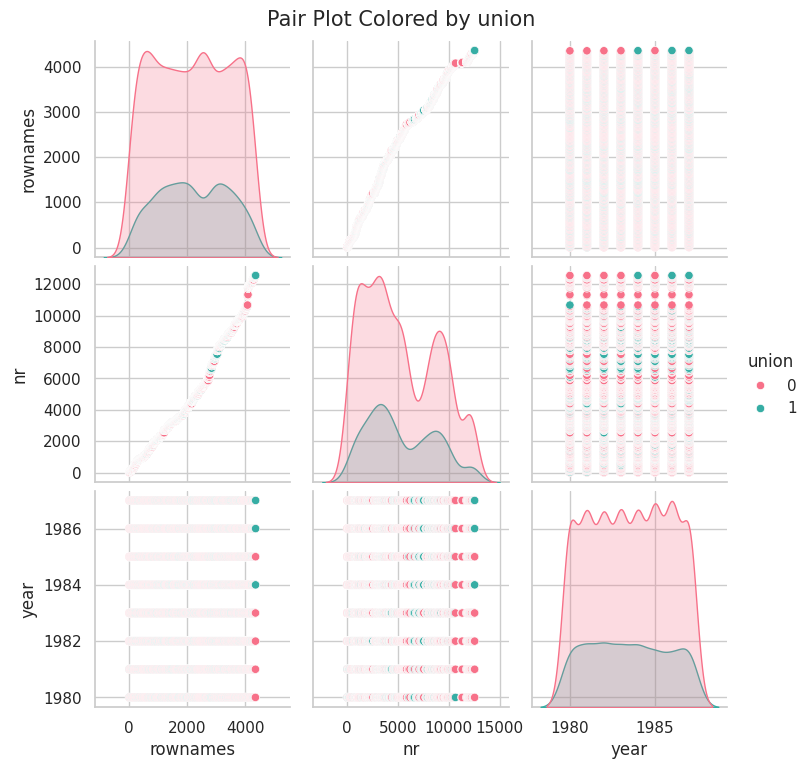

In [24]:
sns.pairplot(df, vars=num_cols[:3], hue=categorical_columns[0], palette='husl')

plt.suptitle("Pair Plot Colored by " + categorical_columns[0], y=1.02, fontsize=15)
plt.show()

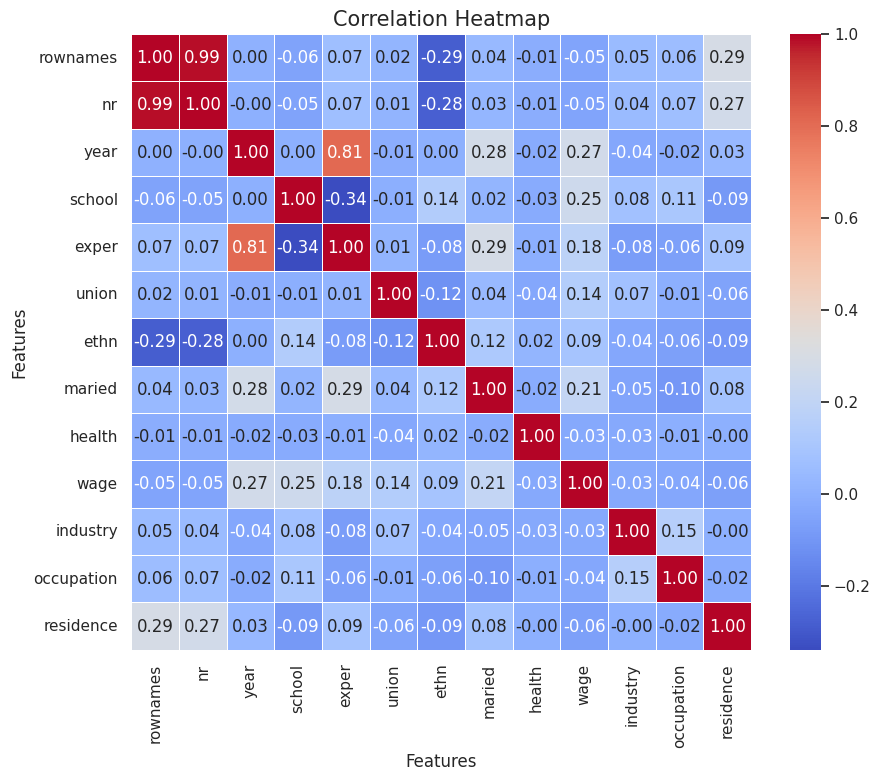

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=15)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()

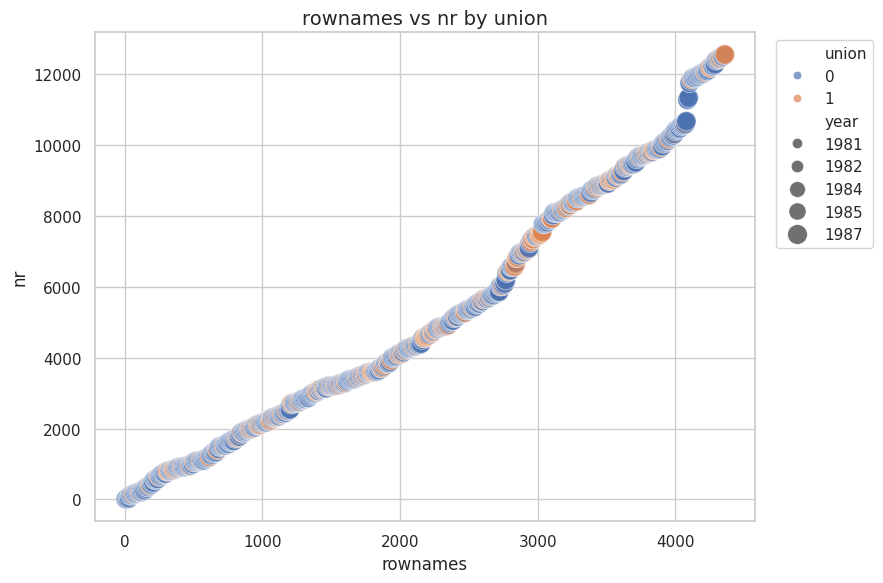

In [26]:
plt.figure(figsize=(9,6))

sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]],
                 hue=df[categorical_columns[0]], size=df[num_cols[2]] if len(num_cols) > 2 else None,
                 palette='deep', alpha=0.7, sizes=(30,200))

plt.title(f'{num_cols[0]} vs {num_cols[1]} by {categorical_columns[0]}', fontsize=14)
plt.xlabel(num_cols[0], fontsize=12)
plt.ylabel(num_cols[1], fontsize=12)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

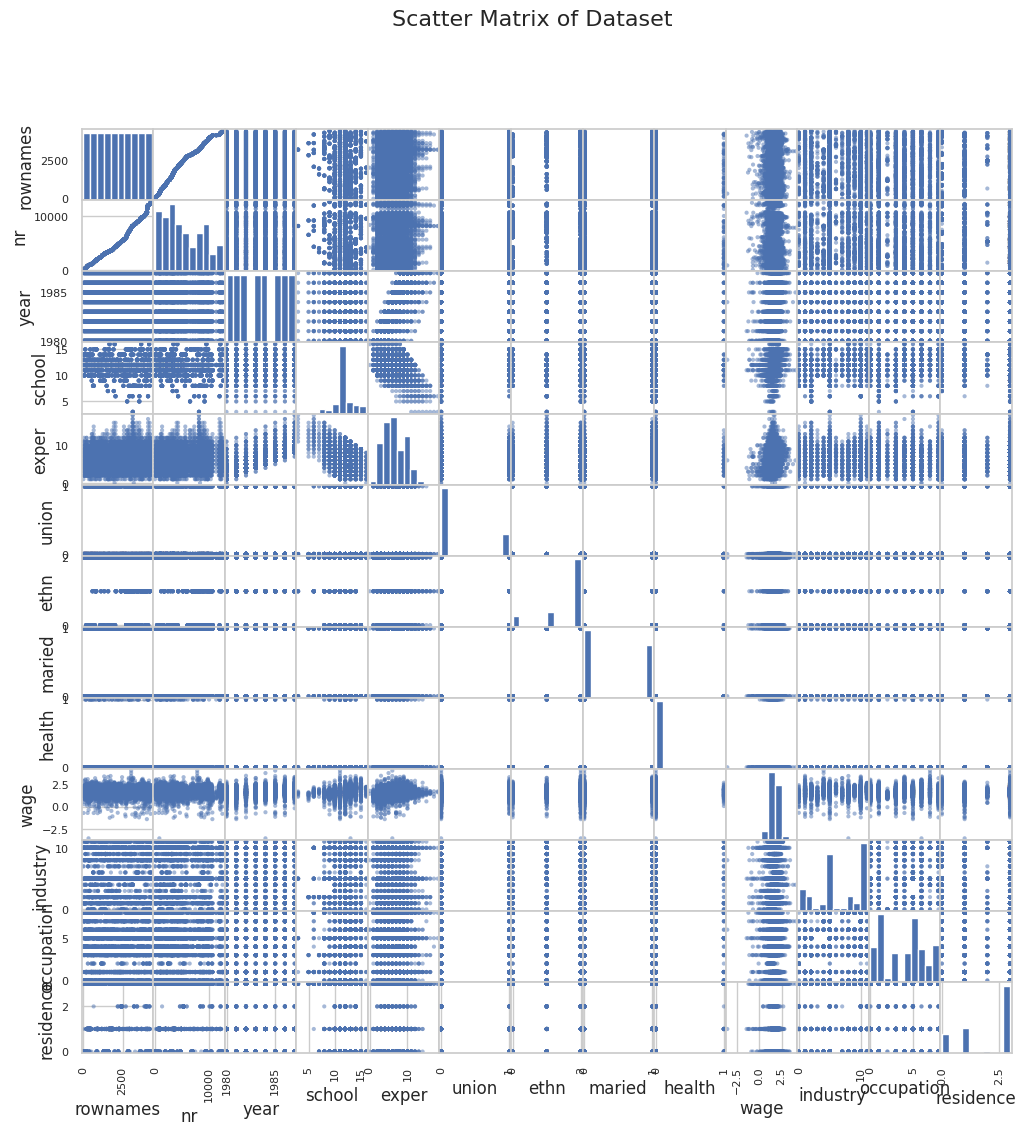

In [27]:
pd.plotting.scatter_matrix(
    df,
    figsize=(12,12),
    diagonal='hist'
)

plt.suptitle("Scatter Matrix of Dataset", fontsize=16)

plt.show()

In [28]:
print("EDA Phase 1 Completed Successfully")

print("""
Tasks Completed

✔ Dataset Loaded
✔ Basic Statistical Analysis
✔ Missing Value Handling
✔ Data Cleaning
✔ Data Transformation
✔ Univariate Analysis (3 Graphs)
✔ Bivariate Analysis (3 Graphs)
✔ Multivariate Analysis (3 Graphs)
""")

EDA Phase 1 Completed Successfully

Tasks Completed

✔ Dataset Loaded
✔ Basic Statistical Analysis
✔ Missing Value Handling
✔ Data Cleaning
✔ Data Transformation
✔ Univariate Analysis (3 Graphs)
✔ Bivariate Analysis (3 Graphs)
✔ Multivariate Analysis (3 Graphs)



# PHASE II - EXPLORATORY DATA ANALYSIS

## BCSE331L - Exploratory Data Analysis

**Name:** Oleti Sree Vathsa  
**Register Number:** 23BDS0143

### Phase II
- 1D Statistical Analysis
- 2D Statistical Analysis
- 3D Statistical Analysis
- K-Means Clustering
- Hierarchical Clustering

In [30]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

from mpl_toolkits.mplot3d import Axes3D

sns.set_style("whitegrid")

print("Phase II libraries loaded successfully - 23BDS0143")

Phase II libraries loaded successfully - 23BDS0143


# 1D STATISTICAL ANALYSIS

In [31]:


phase2_numeric = df.select_dtypes(include=np.number).columns.tolist()

# Remove identifier columns from statistical visualization
analysis_cols = [
    col for col in phase2_numeric
    if col not in ["rownames", "nr"]
]

statistical_summary = pd.DataFrame(index=analysis_cols)

statistical_summary["Mean"] = df[analysis_cols].mean()
statistical_summary["Median"] = df[analysis_cols].median()
statistical_summary["Mode"] = df[analysis_cols].mode().iloc[0]
statistical_summary["Variance"] = df[analysis_cols].var()
statistical_summary["Std_Deviation"] = df[analysis_cols].std()
statistical_summary["Minimum"] = df[analysis_cols].min()
statistical_summary["Q1"] = df[analysis_cols].quantile(0.25)
statistical_summary["Q2_Median"] = df[analysis_cols].quantile(0.50)
statistical_summary["Q3"] = df[analysis_cols].quantile(0.75)
statistical_summary["Maximum"] = df[analysis_cols].max()
statistical_summary["Skewness"] = df[analysis_cols].skew()
statistical_summary["Kurtosis"] = df[analysis_cols].kurtosis()

display(statistical_summary.round(3))

,Mean,Median,Mode,Variance,Std_Deviation,Minimum,Q1,Q2_Median,Q3,Maximum,Skewness,Kurtosis
year,1983.500,1983.500,1980.000,5.251,2.292,1980.000,1981.750,1983.500,1985.250,1987.000,0.000,-1.238
school,11.767,12.000,12.000,3.049,1.746,3.000,11.000,12.000,12.000,16.000,-0.752,2.452
exper,6.515,6.000,8.000,7.986,2.826,0.000,4.000,6.000,9.000,18.000,0.318,-0.107
union,0.244,0.000,0.000,0.185,0.430,0.000,0.000,0.000,0.000,1.000,1.192,-0.579
ethn,1.613,2.000,2.000,0.469,0.685,0.000,1.000,2.000,2.000,2.000,-1.493,0.741
maried,0.439,0.000,0.000,0.246,0.496,0.000,0.000,0.000,1.000,1.000,0.246,-1.940
health,0.017,0.000,0.000,0.017,0.129,0.000,0.000,0.000,0.000,1.000,7.482,53.999
wage,1.649,1.671,1.683,0.284,0.533,-3.579,1.351,1.671,1.991,4.052,-0.934,4.937
industry,6.417,5.000,5.000,11.263,3.356,0.000,5.000,5.000,10.000,11.000,-0.246,-1.200
occupation,3.827,4.000,1.000,6.800,2.608,0.000,1.000,4.000,6.000,8.000,0.020,-1.241


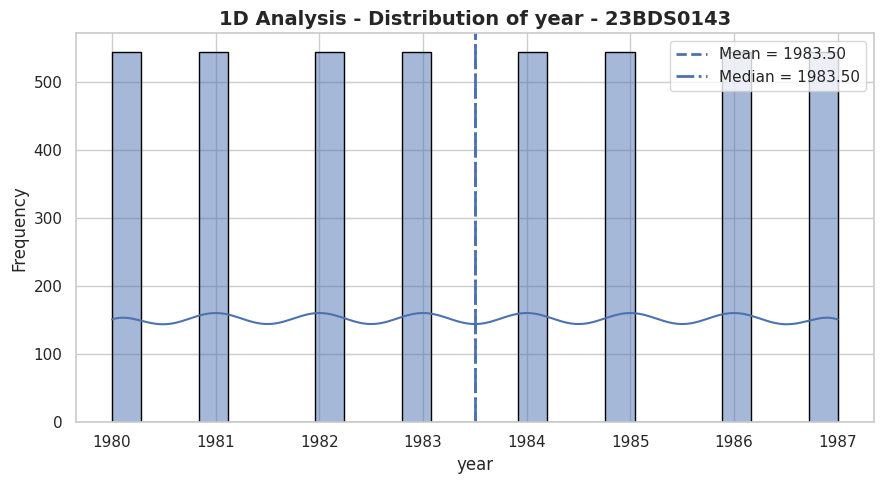

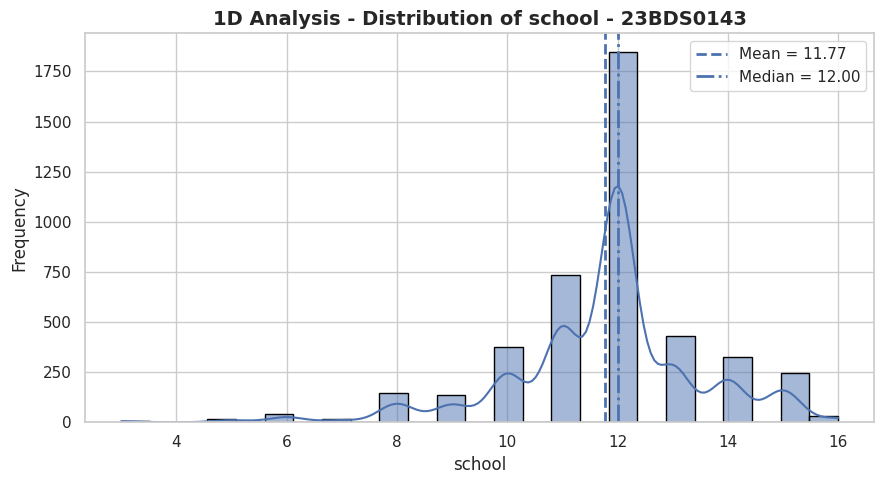

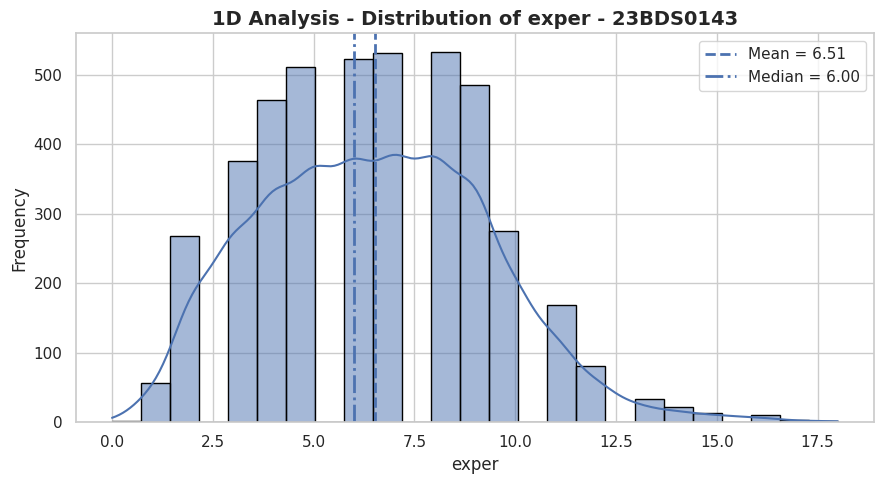

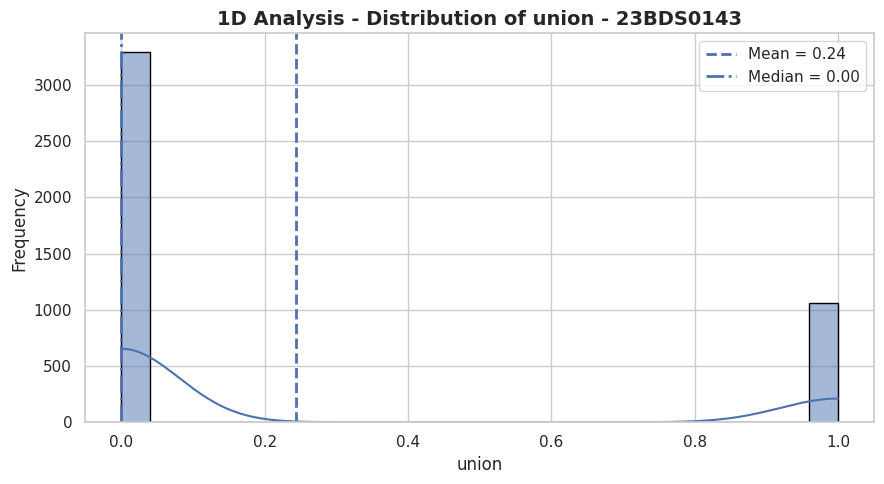

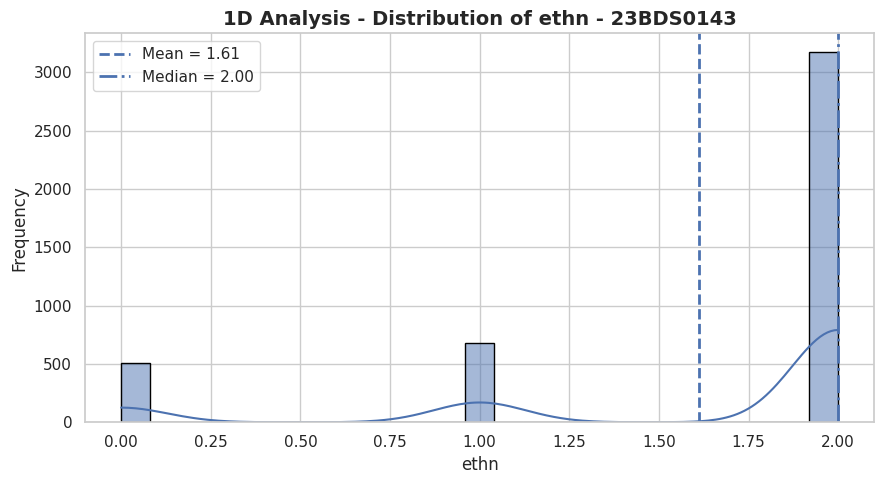

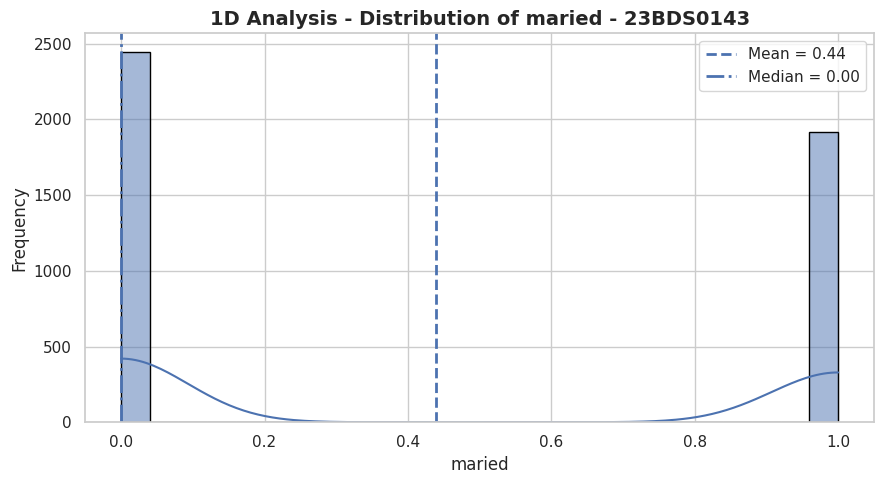

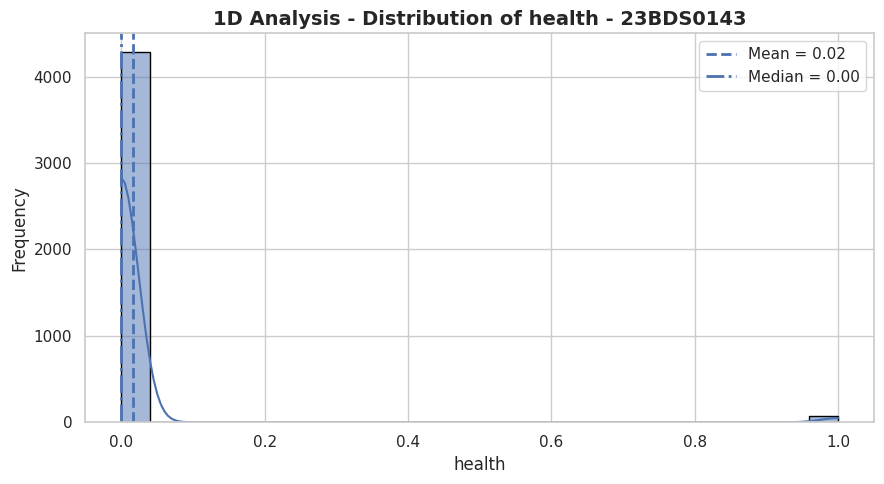

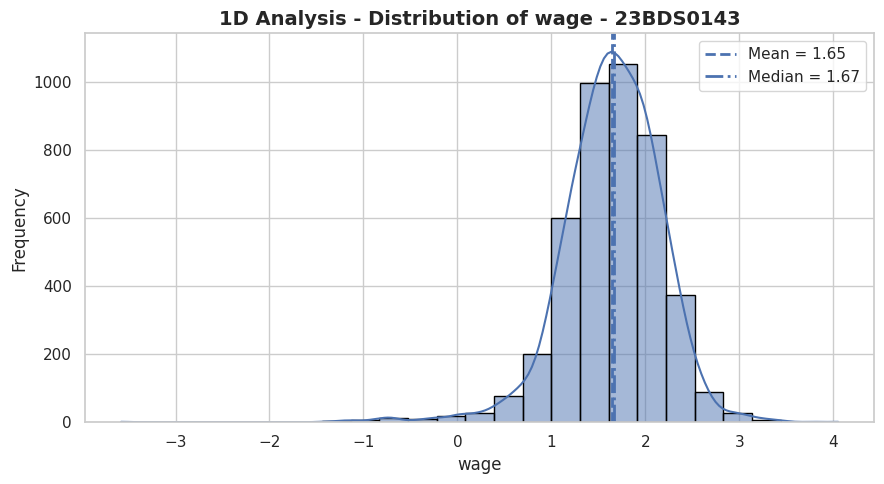

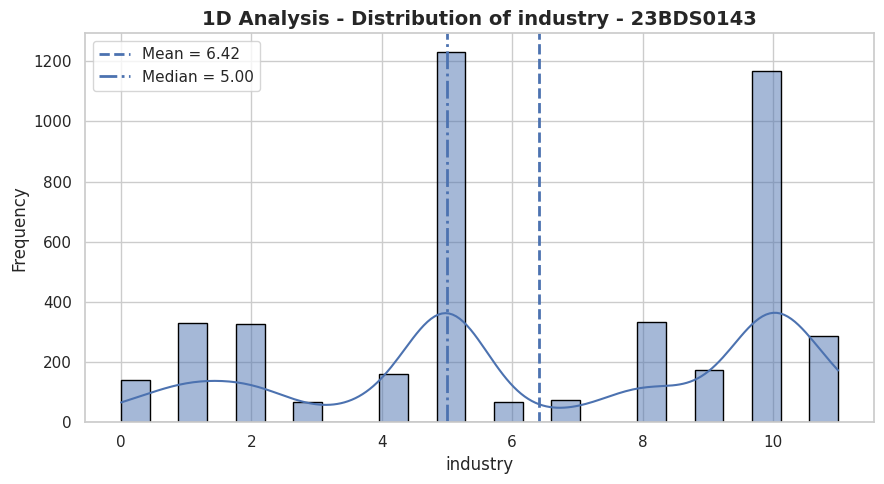

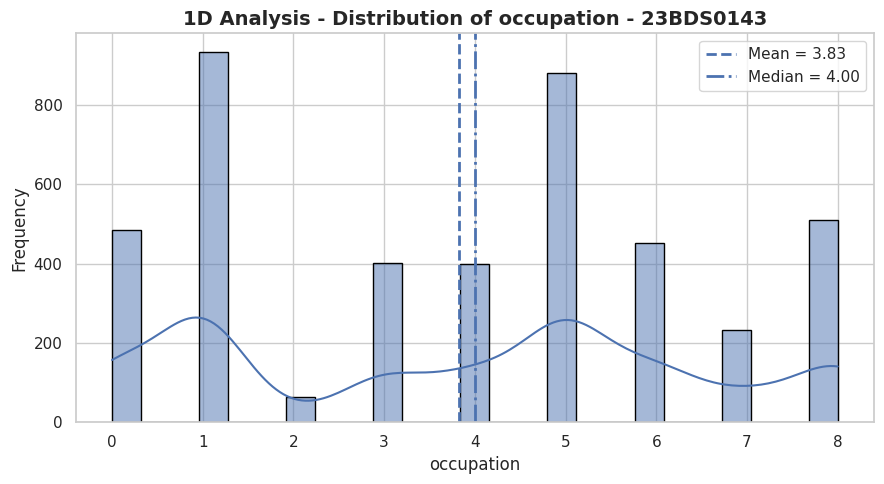

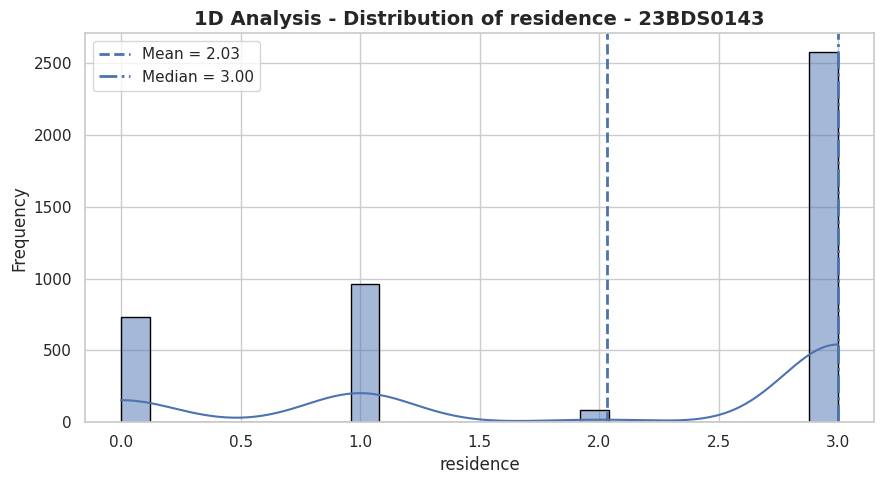

In [32]:


for col in analysis_cols:

    plt.figure(figsize=(9, 5))

    sns.histplot(
        df[col],
        bins=25,
        kde=True,
        edgecolor="black"
    )

    mean_value = df[col].mean()
    median_value = df[col].median()

    plt.axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_value:.2f}"
    )

    plt.axvline(
        median_value,
        linestyle="-.",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )

    plt.title(
        f"1D Analysis - Distribution of {col} - 23BDS0143",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()

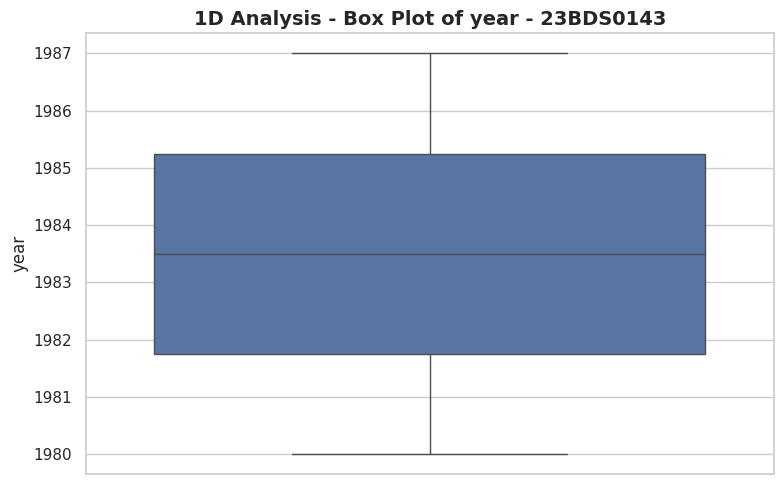

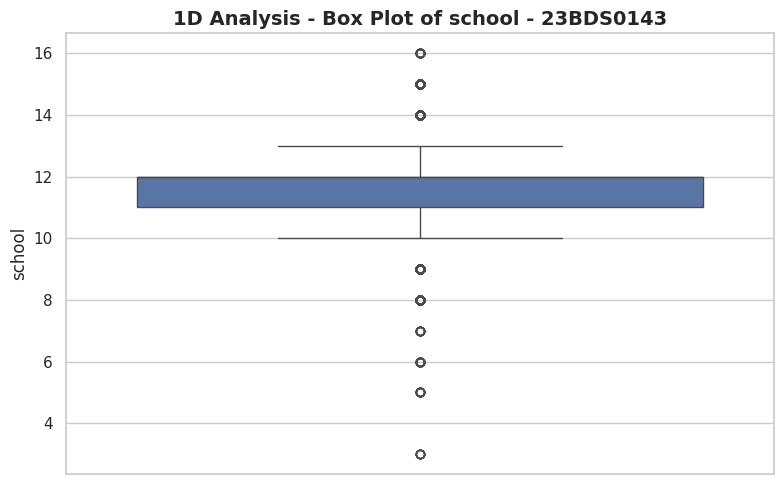

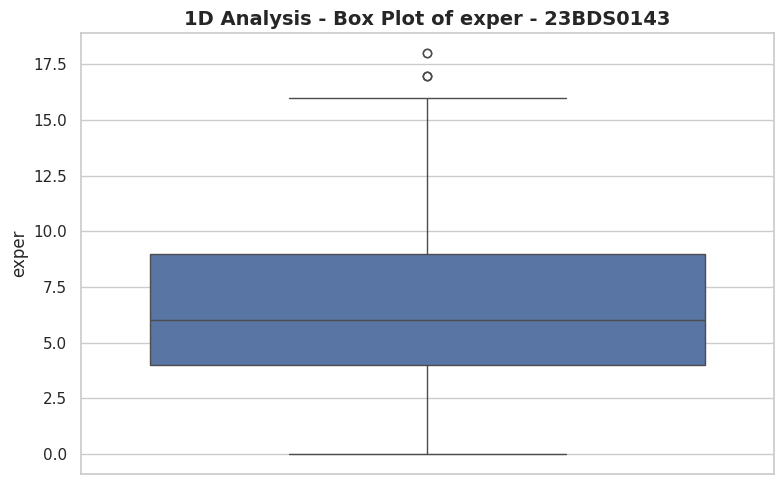

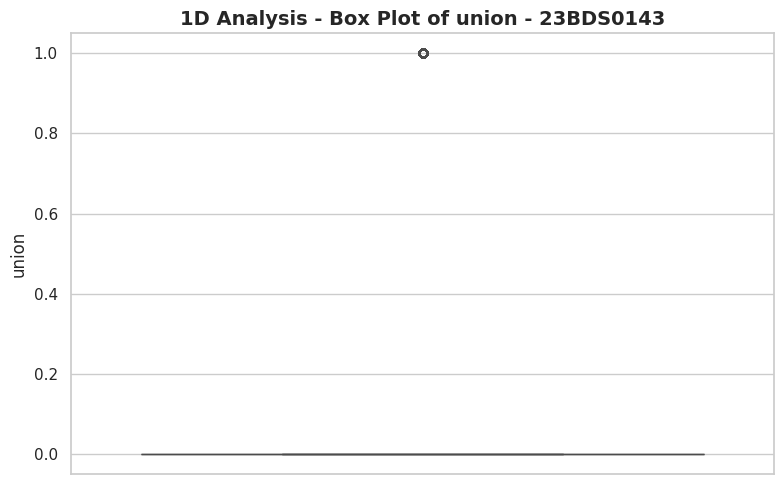

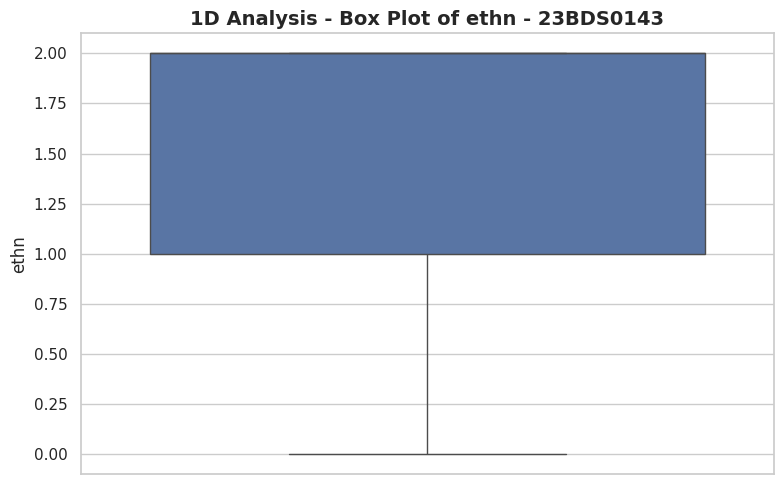

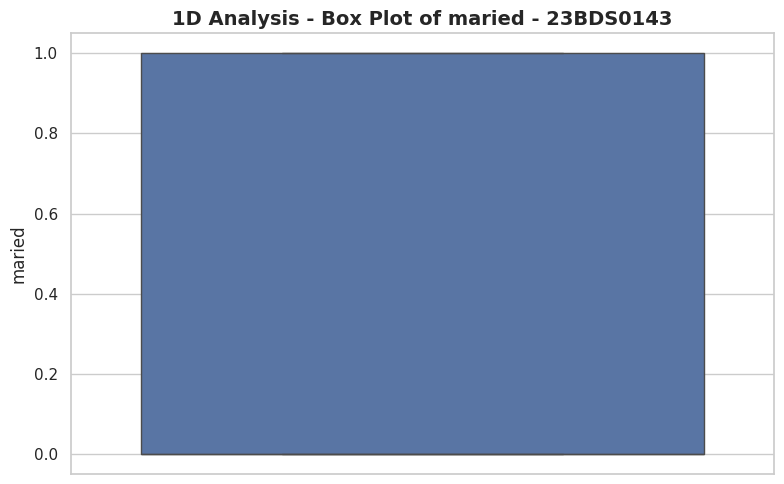

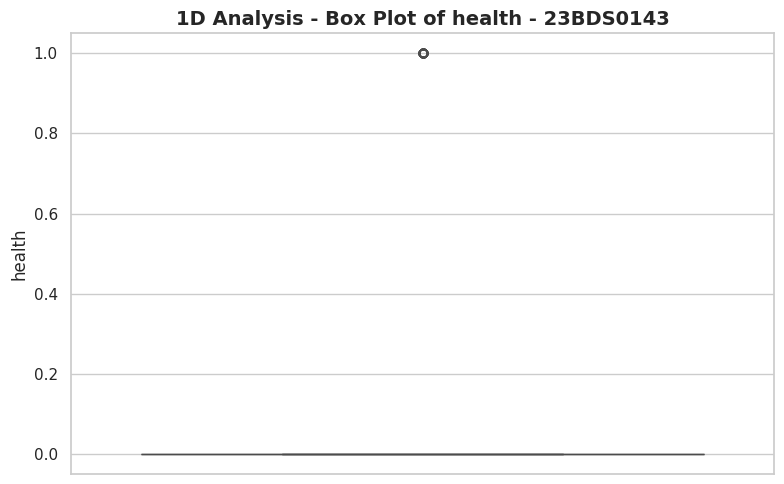

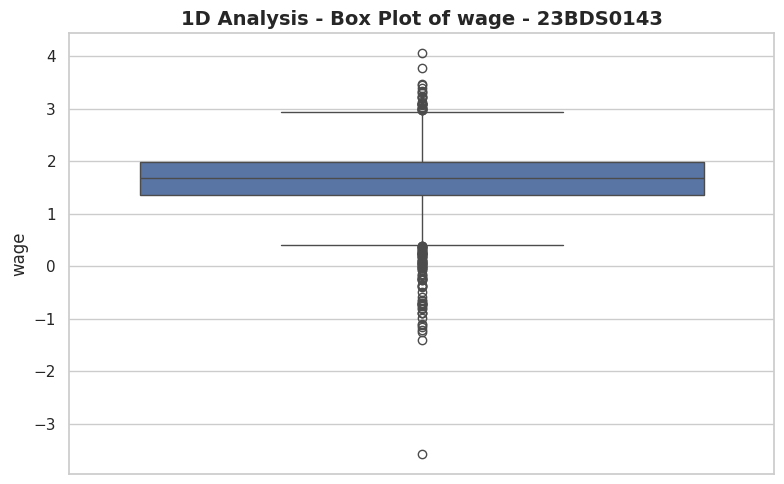

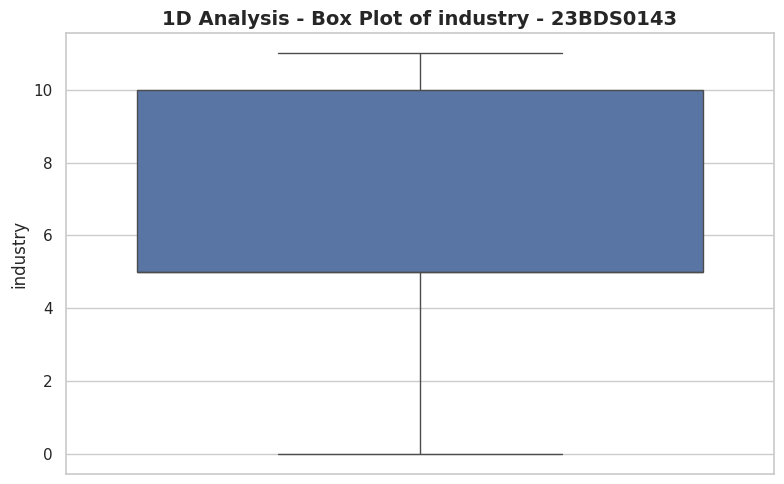

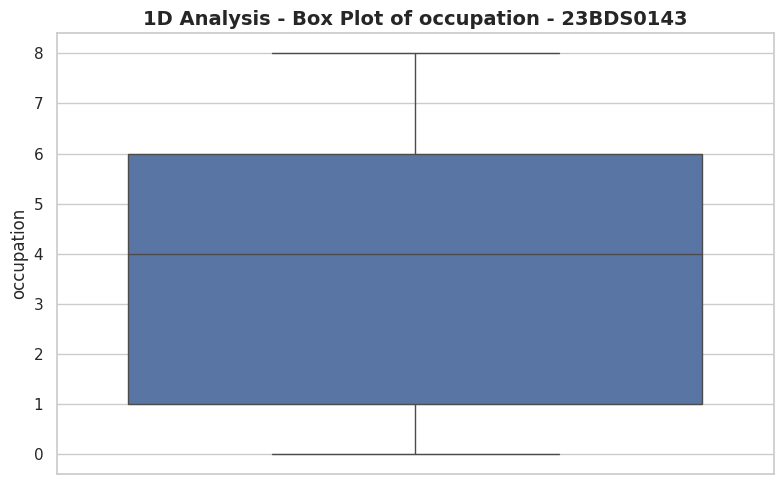

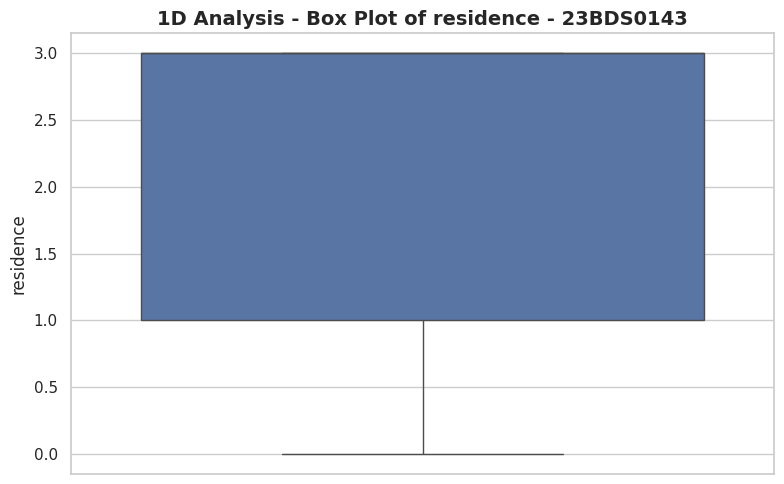

In [33]:


for col in analysis_cols:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        y=df[col]
    )

    plt.title(
        f"1D Analysis - Box Plot of {col} - 23BDS0143",
        fontsize=14,
        fontweight="bold"
    )

    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

,Variable,Skewness,Kurtosis
0,year,0.000,-1.238
1,school,-0.752,2.452
2,exper,0.318,-0.107
3,union,1.192,-0.579
4,ethn,-1.493,0.741
5,maried,0.246,-1.940
6,health,7.482,53.999
7,wage,-0.934,4.937
8,industry,-0.246,-1.200
9,occupation,0.020,-1.241


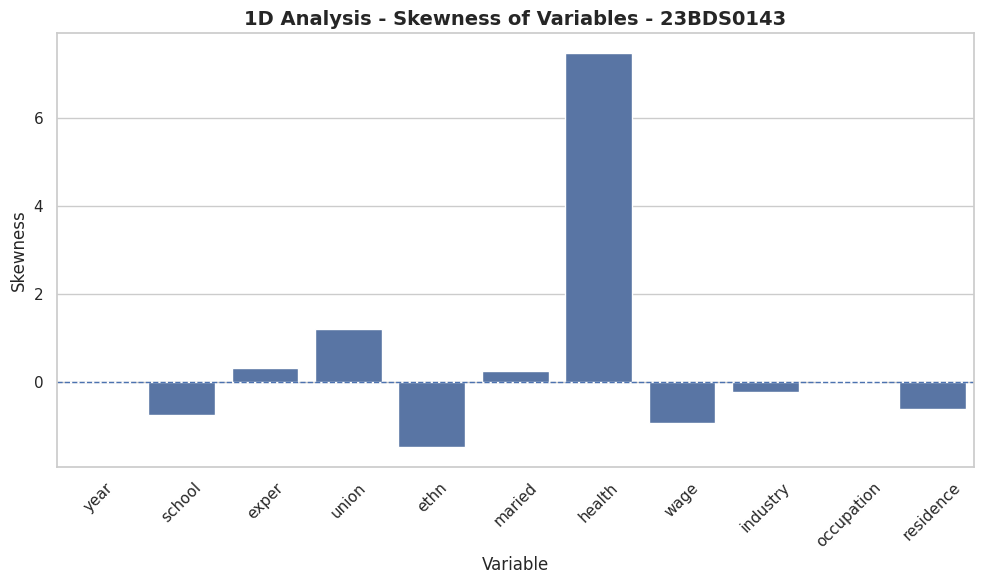

In [34]:


skew_kurt = pd.DataFrame({
    "Variable": analysis_cols,
    "Skewness": [df[col].skew() for col in analysis_cols],
    "Kurtosis": [df[col].kurtosis() for col in analysis_cols]
})

display(skew_kurt.round(3))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=skew_kurt,
    x="Variable",
    y="Skewness"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "1D Analysis - Skewness of Variables - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2D STATISTICAL ANALYSIS

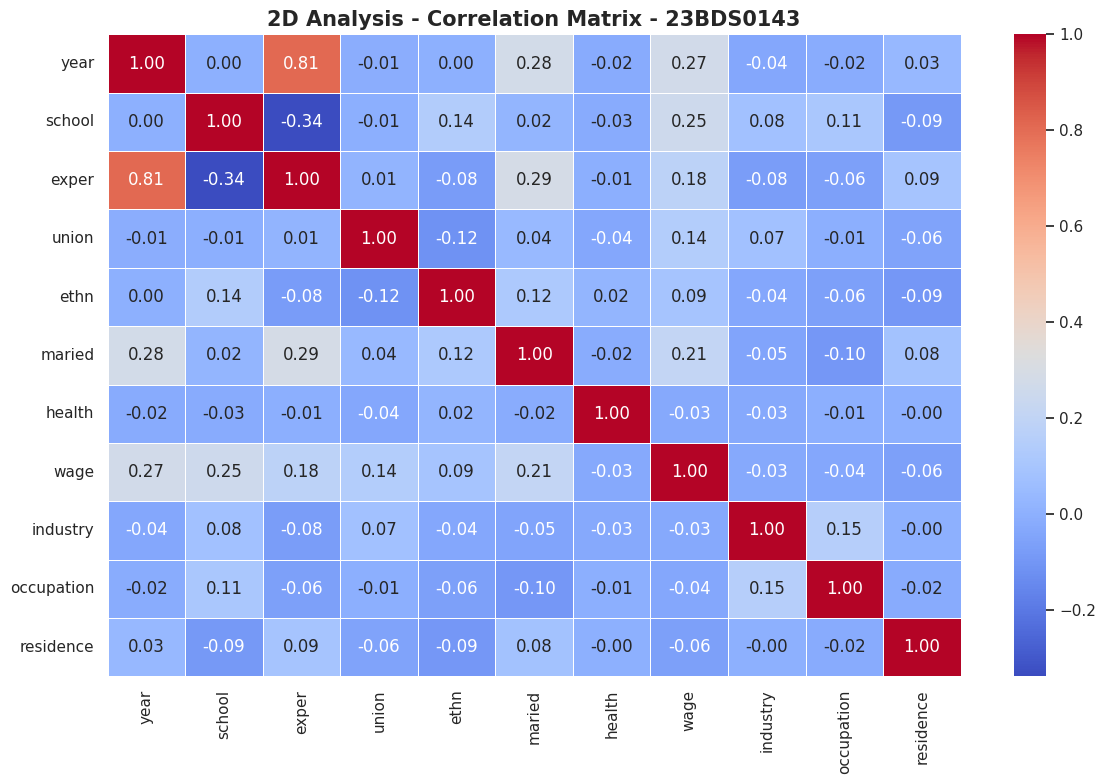

In [35]:

plt.figure(figsize=(12, 8))

corr_matrix = df[analysis_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "2D Analysis - Correlation Matrix - 23BDS0143",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

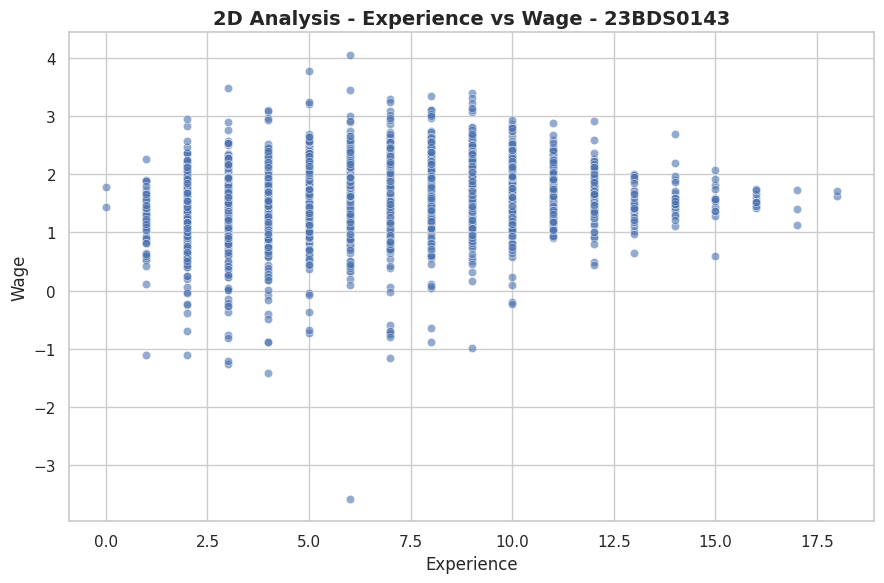

In [36]:


plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="exper",
    y="wage",
    alpha=0.6
)

plt.title(
    "2D Analysis - Experience vs Wage - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Experience")
plt.ylabel("Wage")

plt.tight_layout()
plt.show()

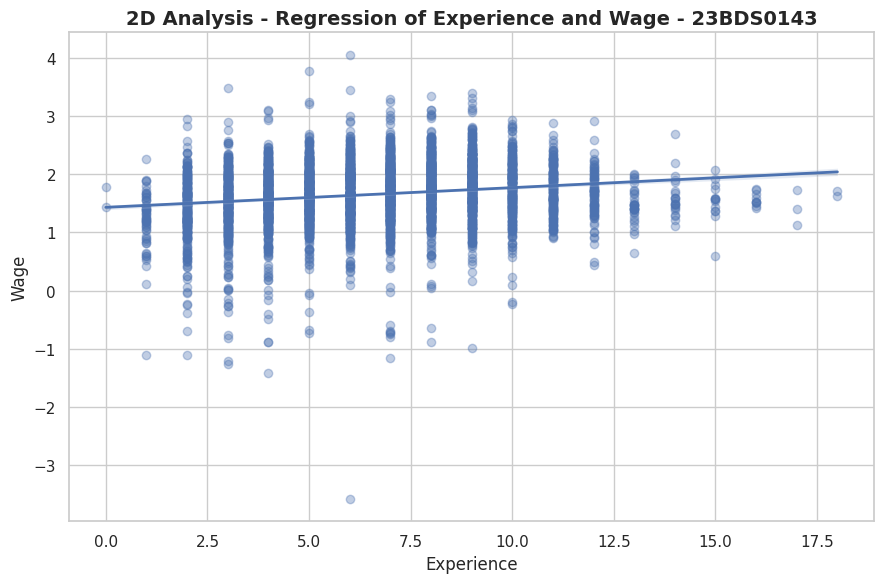

In [37]:


plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="exper",
    y="wage",
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 2}
)

plt.title(
    "2D Analysis - Regression of Experience and Wage - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Experience")
plt.ylabel("Wage")

plt.tight_layout()
plt.show()

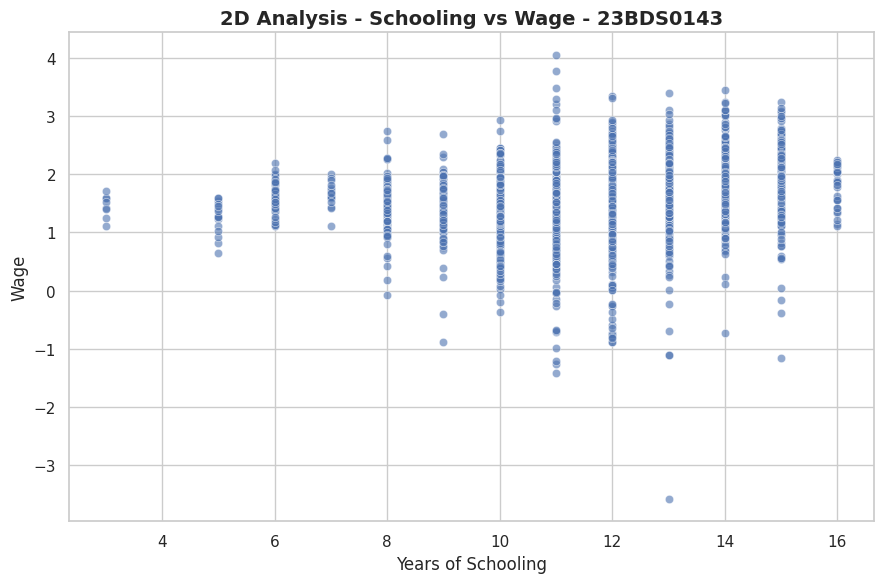

In [38]:


plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="school",
    y="wage",
    alpha=0.6
)

plt.title(
    "2D Analysis - Schooling vs Wage - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Years of Schooling")
plt.ylabel("Wage")

plt.tight_layout()
plt.show()

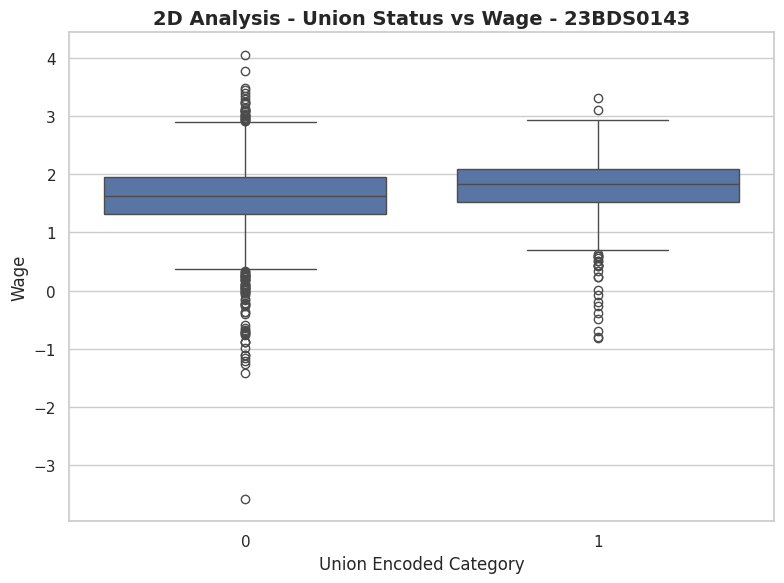

In [39]:


plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="union",
    y="wage"
)

plt.title(
    "2D Analysis - Union Status vs Wage - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Union Encoded Category")
plt.ylabel("Wage")

plt.tight_layout()
plt.show()

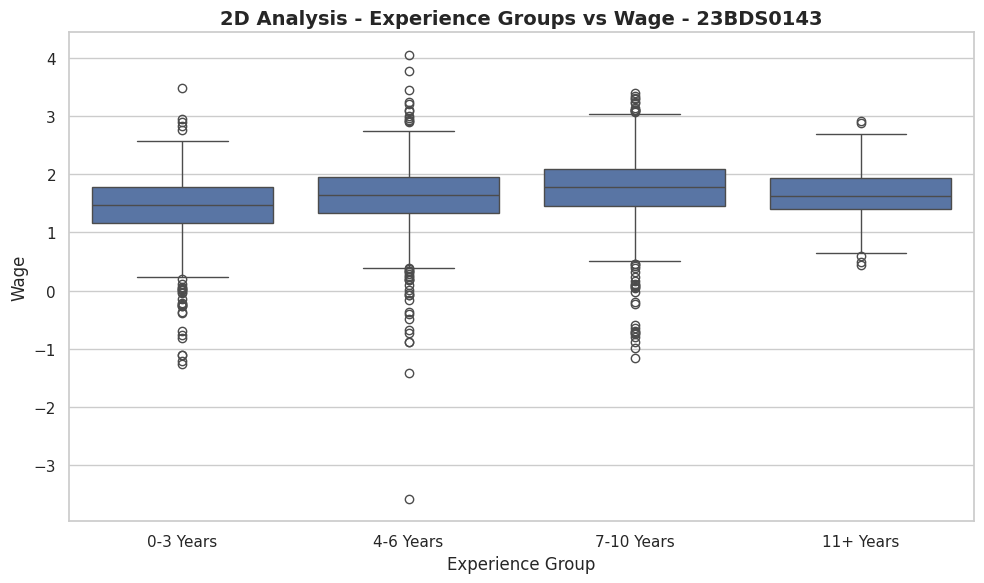

In [40]:


df["Experience_Group"] = pd.cut(
    df["exper"],
    bins=[-1, 3, 6, 10, 20],
    labels=[
        "0-3 Years",
        "4-6 Years",
        "7-10 Years",
        "11+ Years"
    ]
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Experience_Group",
    y="wage"
)

plt.title(
    "2D Analysis - Experience Groups vs Wage - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Experience Group")
plt.ylabel("Wage")

plt.tight_layout()
plt.show()

# 3D STATISTICAL ANALYSIS

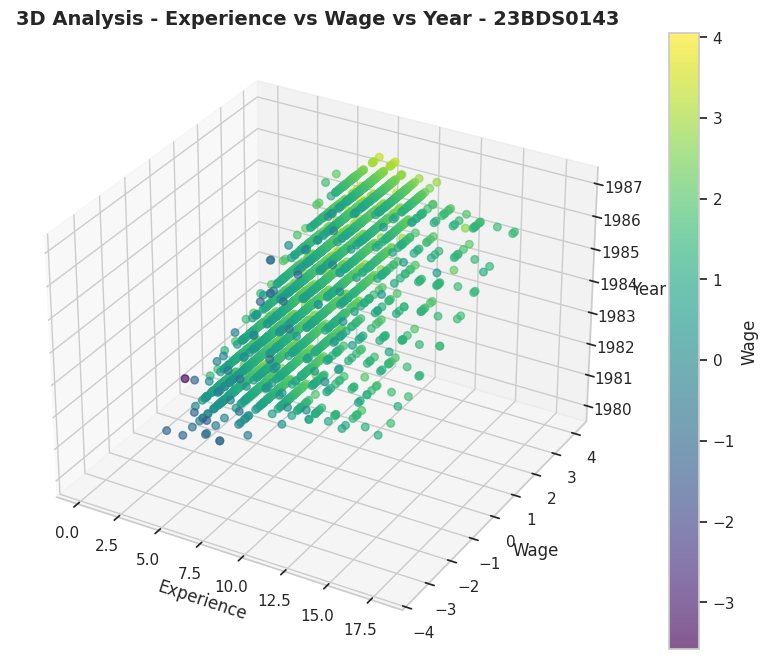

In [41]:


fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["exper"],
    df["wage"],
    df["year"],
    c=df["wage"],
    cmap="viridis",
    alpha=0.65,
    s=30
)

ax.set_xlabel("Experience")
ax.set_ylabel("Wage")
ax.set_zlabel("Year")

ax.set_title(
    "3D Analysis - Experience vs Wage vs Year - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Wage"
)

plt.show()

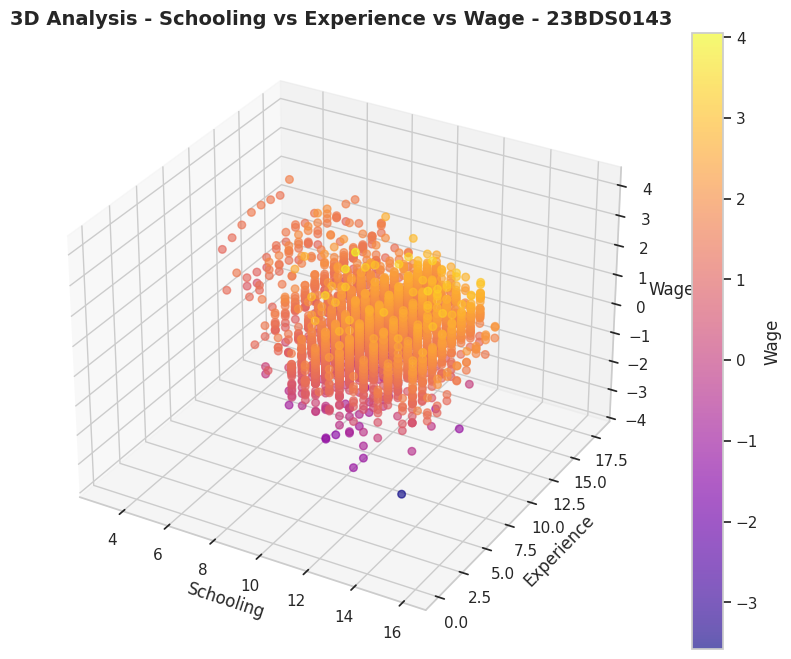

In [42]:

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["school"],
    df["exper"],
    df["wage"],
    c=df["wage"],
    cmap="plasma",
    alpha=0.65,
    s=30
)

ax.set_xlabel("Schooling")
ax.set_ylabel("Experience")
ax.set_zlabel("Wage")

ax.set_title(
    "3D Analysis - Schooling vs Experience vs Wage - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Wage"
)

plt.show()

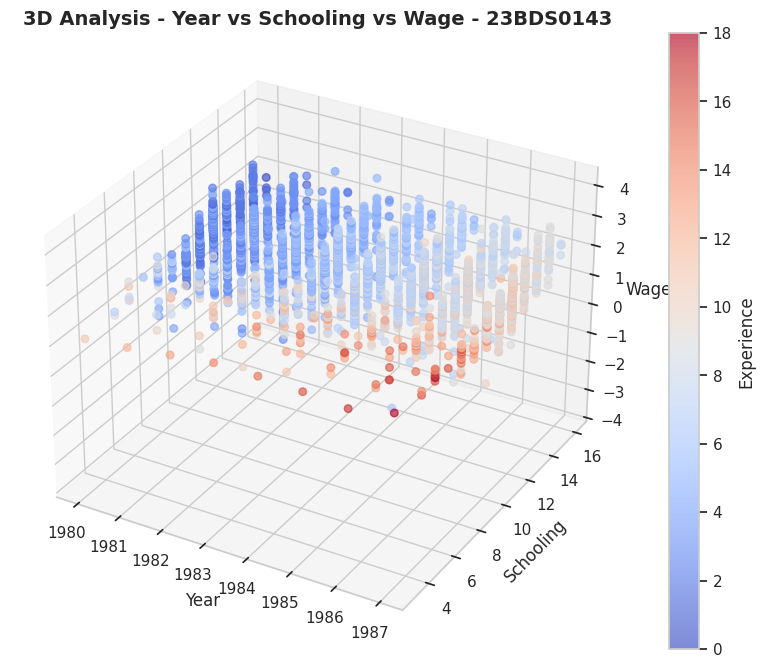

In [43]:



fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["year"],
    df["school"],
    df["wage"],
    c=df["exper"],
    cmap="coolwarm",
    alpha=0.65,
    s=30
)

ax.set_xlabel("Year")
ax.set_ylabel("Schooling")
ax.set_zlabel("Wage")

ax.set_title(
    "3D Analysis - Year vs Schooling vs Wage - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Experience"
)

plt.show()

# K-MEANS CLUSTERING

In [44]:


cluster_features = [
    "school",
    "exper",
    "wage"
]

X = df[cluster_features].copy()

print("Features selected for K-Means:")
print(cluster_features)

print("\nShape of clustering dataset:")
print(X.shape)

# Standardization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData standardized successfully - 23BDS0143")

Features selected for K-Means:
['school', 'exper', 'wage']

Shape of clustering dataset:
(4360, 3)

Data standardized successfully - 23BDS0143


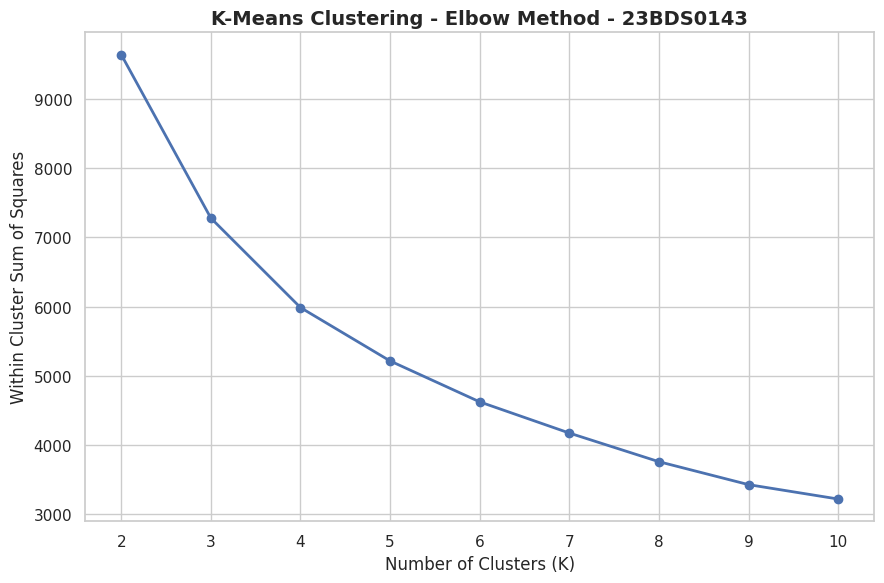

In [45]:

# K-MEANS - ELBOW METHOD



inertia_values = []

K_values = range(2, 11)

for k in K_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia_values.append(model.inertia_)

plt.figure(figsize=(9, 6))

plt.plot(
    K_values,
    inertia_values,
    marker="o",
    linewidth=2
)

plt.title(
    "K-Means Clustering - Elbow Method - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within Cluster Sum of Squares")

plt.xticks(K_values)
plt.grid(True)

plt.tight_layout()
plt.show()

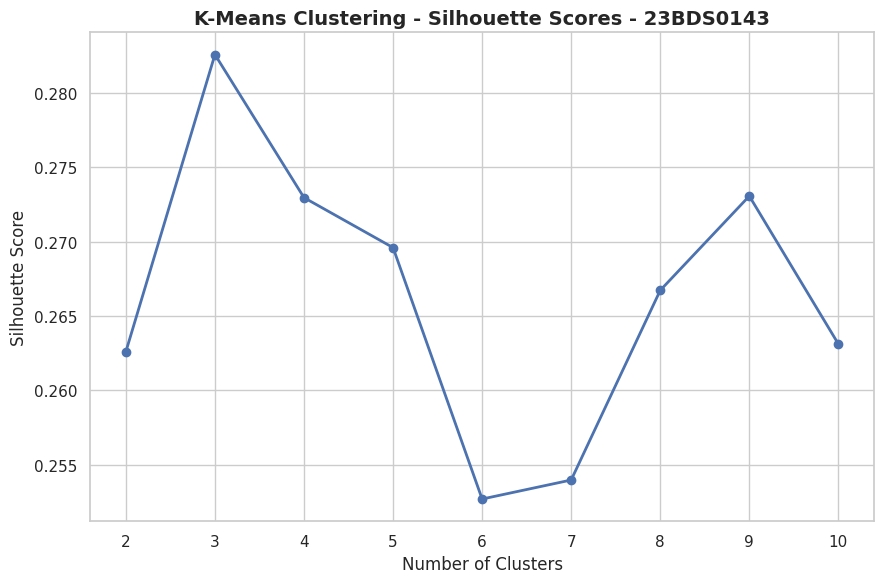

Suggested number of clusters: 3


In [46]:

# K-MEANS - SILHOUETTE SCORE


silhouette_values = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_values.append(score)

plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    silhouette_values,
    marker="o",
    linewidth=2
)

plt.title(
    "K-Means Clustering - Silhouette Scores - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))
plt.grid(True)

plt.tight_layout()
plt.show()

best_k = range(2, 11)[
    np.argmax(silhouette_values)
]

print("Suggested number of clusters:", best_k)

In [47]:


kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans_model.fit_predict(
    X_scaled
)

print("K-Means clustering completed successfully.")

print("\nCluster Distribution:")

display(
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Number of Records")
)

K-Means clustering completed successfully.

Cluster Distribution:


,Number of Records
KMeans_Cluster,
0,1699
1,625
2,2036


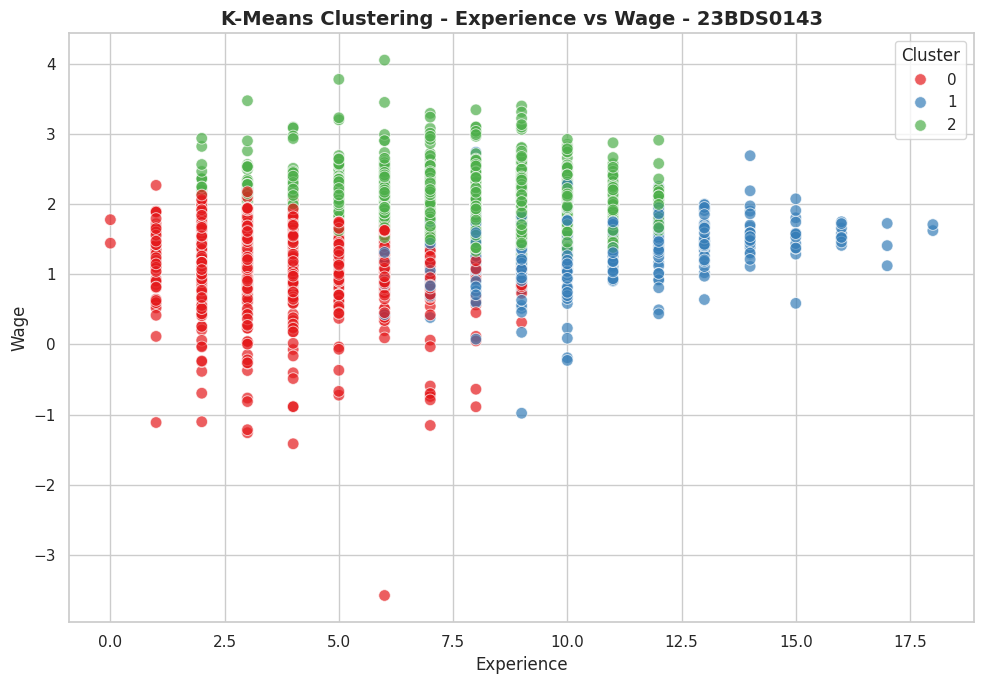

In [48]:


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="exper",
    y="wage",
    hue="KMeans_Cluster",
    palette="Set1",
    s=70,
    alpha=0.7
)

plt.title(
    "K-Means Clustering - Experience vs Wage - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Experience")
plt.ylabel("Wage")

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

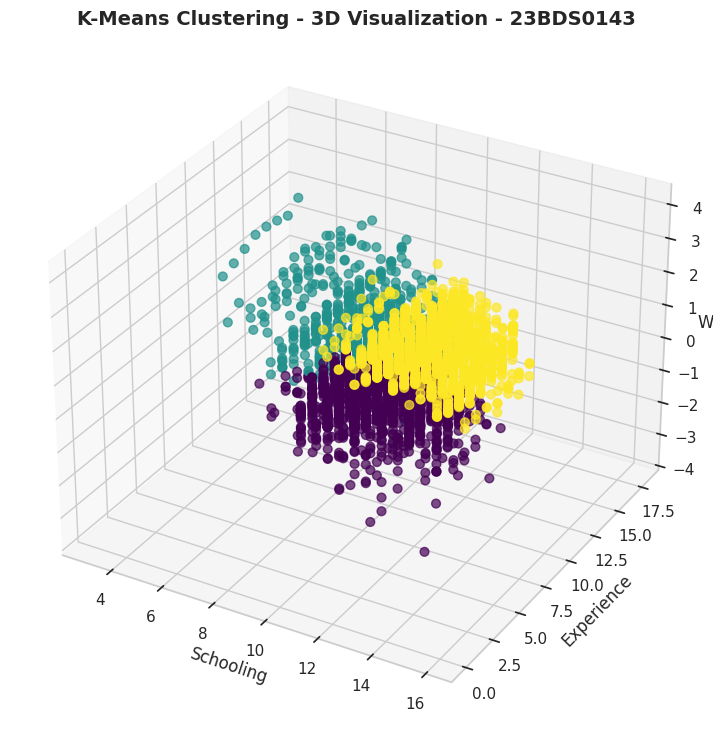

In [49]:

fig = plt.figure(figsize=(12, 9))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["school"],
    df["exper"],
    df["wage"],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    s=40,
    alpha=0.7
)

ax.set_xlabel("Schooling")
ax.set_ylabel("Experience")
ax.set_zlabel("Wage")

ax.set_title(
    "K-Means Clustering - 3D Visualization - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.show()

In [50]:

cluster_profile = df.groupby(
    "KMeans_Cluster"
)[cluster_features].agg(
    ["count", "mean", "median", "std"]
)

print("K-Means Cluster Profile - 23BDS0143")

display(cluster_profile.round(3))

K-Means Cluster Profile - 23BDS0143


school                       exper                       wage  \
                count    mean median    std count   mean median    std count   
KMeans_Cluster                                                                 
0                1699  11.920   12.0  1.269  1699  4.186    4.0  1.730  1699   
1                 625   9.042    9.0  1.737   625  9.702    9.0  2.467   625   
2                2036  12.476   12.0  1.208  2036  7.479    8.0  2.041  2036   

                                     
                 mean median    std  
KMeans_Cluster                       
0               1.310  1.380  0.489  
1               1.402  1.409  0.390  
2               2.008  1.995  0.344

# HIERARCHICAL CLUSTERING

In [51]:

sample_size = min(300, len(X_scaled))

random_state = np.random.RandomState(42)

sample_indices = random_state.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_hierarchical = X_scaled[sample_indices]

print(
    "Number of observations used for dendrogram:",
    sample_size
)

Number of observations used for dendrogram: 300


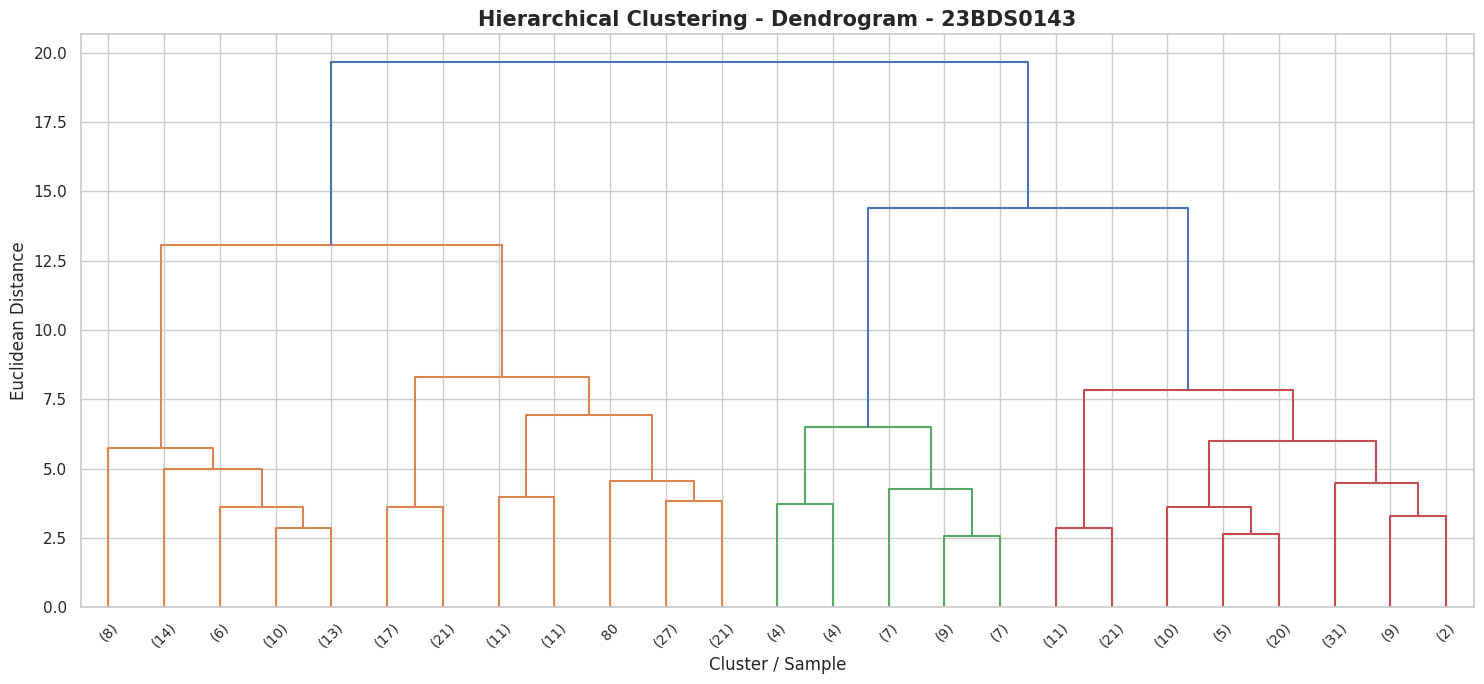

In [52]:

linkage_matrix = linkage(
    X_hierarchical,
    method="ward"
)

plt.figure(figsize=(15, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=25,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title(
    "Hierarchical Clustering - Dendrogram - 23BDS0143",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Cluster / Sample")
plt.ylabel("Euclidean Distance")

plt.tight_layout()
plt.show()

In [53]:

# HIERARCHICAL CLUSTERING - AGGLOMERATIVE MODEL


hierarchical_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_hierarchical
)

print("Hierarchical clustering completed successfully.")

print("\nCluster Distribution:")

unique_clusters, cluster_counts = np.unique(
    hierarchical_labels,
    return_counts=True
)

for cluster, count in zip(
    unique_clusters,
    cluster_counts
):
    print(
        f"Cluster {cluster}: {count} observations"
    )

Hierarchical clustering completed successfully.

Cluster Distribution:
Cluster 0: 160 observations
Cluster 1: 109 observations
Cluster 2: 31 observations


In [54]:


hierarchical_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_hierarchical
)

print("Hierarchical clustering completed successfully.")

print("\nCluster Distribution:")

unique_clusters, cluster_counts = np.unique(
    hierarchical_labels,
    return_counts=True
)

for cluster, count in zip(
    unique_clusters,
    cluster_counts
):
    print(
        f"Cluster {cluster}: {count} observations"
    )

Hierarchical clustering completed successfully.

Cluster Distribution:
Cluster 0: 160 observations
Cluster 1: 109 observations
Cluster 2: 31 observations


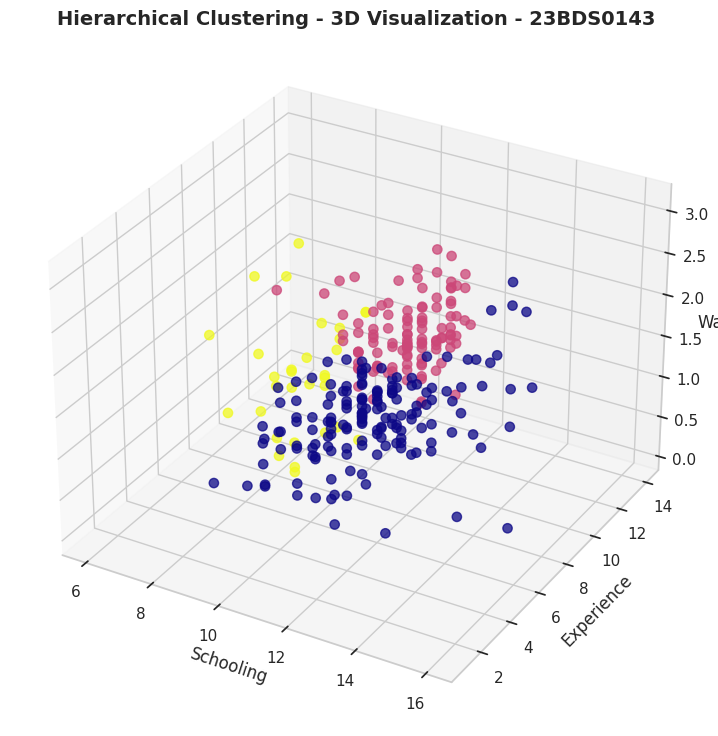

In [57]:

sample_size = min(300, len(X_scaled))

random_state = np.random.RandomState(42)

sample_indices = random_state.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

sample_df = df.iloc[sample_indices].copy()


X_hierarchical = X_scaled[sample_indices]

hierarchical_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_hierarchical
)


sample_df["Hierarchical_Cluster"] = hierarchical_labels




fig = plt.figure(figsize=(12, 9))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    sample_df["school"],
    sample_df["exper"],
    sample_df["wage"],
    c=sample_df["Hierarchical_Cluster"],
    cmap="plasma",
    s=45,
    alpha=0.75
)

ax.set_xlabel("Schooling")
ax.set_ylabel("Experience")
ax.set_zlabel("Wage")

ax.set_title(
    "Hierarchical Clustering - 3D Visualization - 23BDS0143",
    fontsize=14,
    fontweight="bold"
)

plt.show()

In [58]:


kmeans_silhouette = silhouette_score(
    X_scaled,
    df["KMeans_Cluster"]
)

hierarchical_silhouette = silhouette_score(
    X_hierarchical,
    hierarchical_labels
)

comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "Hierarchical"
    ],
    "Clusters": [
        best_k,
        best_k
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

display(
    comparison.round(4)
)

,Method,Clusters,Silhouette Score
0,K-Means,3,0.2826
1,Hierarchical,3,0.2790
